# Vanishing-Act — a quantitative teardown 🔬
### SMB with a Lo t-stat · aligned leg Sharpes · the window-split bootstrap · the sign-flip exhibit · quality-not-size

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survived publication?: Busted](https://img.shields.io/badge/Survived_publication%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the size premium on three pairs and find it statistically zero — with the famous 'turn in 2010' dissolving into window noise on the only long series.

> ⚠️ **Not investment advice.** ^RUT/^GSPC 1987–2026 (price indices — no dividends; since large caps yield more, a total-return spread would be *more* negative, so the long history is conservative) + IWM/SPY + IJR/IVV total return, 2000–2026, Yahoo. Sources in [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (vanishing_act/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from vanishing_act import data, strategy as st
from quantlab import repro
ret = repro.as_of(data.fetch_pairs())          # cache-first, pinned to the desk as-of
smb_long = st.smb(ret, "^RUT", "^GSPC")        # the long-history spread (price indices — conservative)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **None** | 39-yr SMB Sharpe 0.00, Lo t 0.02 |
| Tradability | **Mirage** | ETF SMB insignificant; small Sharpe < large on the same months |
| Survived publication? | **Busted** | the whole sample is post-Banz and the premium never showed; the 2010 'turn' is window noise (p = 0.45 on the long series) |

> 💡 *In plain words:* the original factor isn't a decay story — there was nothing on this tape to decay.

## 1 · The claim, steelmanned

- **H₁:** SMB > 0 with |t| > 2 over the long sample.
- **H₂:** small-caps deliver a higher Sharpe than large-caps (same months, same bar).
- **H₃:** sub-period structure — the 'positive then negative around 2010' shape — reflects a real regime change, not window luck.

## 2 · So what? — what rides on each

If H₁/H₂ hold, a size tilt is a free risk-adjusted gain. If they fail, the SMB factor and small-cap allocations rest on a premium nobody can find in 39 years of out-of-sample data. (One thing no split of this sample can test: *post-publication decay* — Banz published in 1981, the data starts in 1987, so there is no 'before' to compare against. McLean–Pontiff needs a pre-publication window; we don't have one.)

## 3 · How we'd know — the protocol

SMB spread per pair → Lo (2002) t-stat → each leg's standalone Sharpe **on the pair's common months** (aligned by construction in `leg_summary`) → the trailing-10y sign-flip exhibit → the post-hoc 2010 split scored with a circular-block-bootstrap p-value on the pre/post difference → the quality caveat (S&P 600 vs Russell 2000).

## 4 · The teardown

### 4.1 The spread, with a t-stat, across pairs

In [2]:
rows={}
for k,(a,b) in data.PAIRS.items():
    if a in ret and b in ret:
        s=st.smb_stats(st.smb(ret,a,b)); rows[f'{a}−{b}']={'SMB %/yr':s['mean_ann']*100,'Sharpe':s['sharpe'],'Lo t':s['tstat'],'n':s['n']}
display(pd.DataFrame(rows).T.round(3))

,SMB %/yr,Sharpe,Lo t,n
^RUT−^GSPC,0.028,0.003,0.016,464.0
IWM−SPY,0.909,0.090,0.459,312.0
IJR−IVV,1.934,0.188,0.960,312.0


> 💡 *In plain words:* not one |t| reaches 2 — the longest series sits at 0.02. **H₁ rejected** — no detectable premium.

### 4.2 Small-caps trail on Sharpe — on the same months

In [3]:
for a,b in data.PAIRS.values():
    if a in ret and b in ret:
        L=st.leg_summary(ret,a,b)
        print(f"{L['start'].date()}..{L['end'].date()} ({L['n']} mo)  {a} Sharpe {L['small']['sharpe']:.2f}  vs  {b} Sharpe {L['large']['sharpe']:.2f}")

1987-10-31..2026-05-31 (464 mo)  ^RUT Sharpe 0.47  vs  ^GSPC Sharpe 0.62
2000-06-30..2026-05-31 (312 mo)  IWM Sharpe 0.51  vs  SPY Sharpe 0.61
2000-06-30..2026-05-31 (312 mo)  IJR Sharpe 0.58  vs  IVV Sharpe 0.61


> 💡 *In plain words:* every leg pair is compared on its intersection — aligning samples matters (SPY's Sharpe is 0.77 from its 1993 inception but 0.61 on IWM's 2000–2026 months; only the latter is a fair comparison). On equal footing the 'risk premium' delivers *less* risk-adjusted return than the large-cap index. **H₂ rejected.**

### 4.3 The 2010 split, scored honestly

,pre %/yr,post %/yr,diff %/yr,bootstrap p
^RUT−^GSPC,1.11,-1.44,2.55,0.45
IWM−SPY,5.75,-1.92,7.66,0.03
IJR−IVV,7.69,-1.43,9.12,0.02


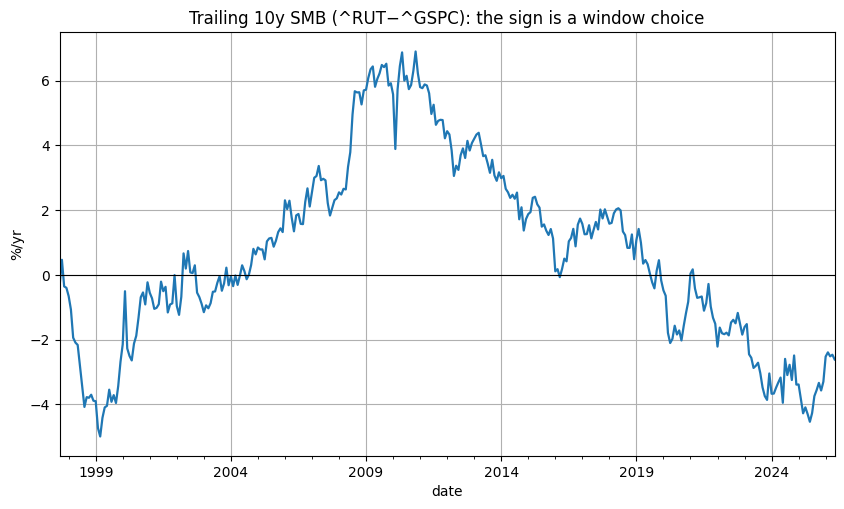

In [4]:
rows={}
for k,(a,b) in data.PAIRS.items():
    if a in ret and b in ret:
        d=st.split_difference(st.smb(ret,a,b),cut_year=2010)
        rows[f'{a}−{b}']={'pre %/yr':d['pre_ann']*100,'post %/yr':d['post_ann']*100,'diff %/yr':d['diff_ann']*100,'bootstrap p':d['p_value']}
display(pd.DataFrame(rows).T.round(2))
roll=st.rolling_mean_ann(smb_long,120).dropna()
ax=(roll*100).plot(lw=1.6,title='Trailing 10y SMB (^RUT−^GSPC): the sign is a window choice')
ax.axhline(0,color='k',lw=.8); ax.set_ylabel('%/yr'); plt.show()

> 💡 *In plain words:* the split at 2010 is post-hoc, and on the long series it fails its own test — pre-2010 SMB was +1.1%/yr at Sharpe 0.09 (itself ≈ 0) and the pre/post difference has p = 0.45. The ETF pairs' gap is detectable (p ≈ 0.02–0.03), but both start in 2000 — 19 years *after* publication — so what it captures is one good small-cap decade (the post-dot-com 2000s) followed by a bad one: regime dependence, not a publication event. **H₃ rejected** — and with it the romantic 'arbitraged away after Banz' story; the data can't even show it was there to arbitrage.

### 4.4 What survives is quality, not size

The one pair with a faint positive tilt is **IJR − IVV** (S&P SmallCap 600 vs S&P 500). The S&P 600, unlike the Russell 2000, **screens constituents for positive earnings** — so its edge is a *profitability* screen, exactly the Asness et al. (2018) *"Size Matters, If You Control Your Junk"* result. Strip the quality and the size premium is gone.

## 5 · The verdict

H₁, H₂, H₃ all rejected → Signal `NONE`, Tradability `MIRAGE`, survived-publication `BUSTED` — zero over 39 post-publication years.

## 6 · Could you trade it?

A size *tilt* buys a lower Sharpe than the S&P 500. The only live version is a quality screen in disguise. There is no size premium to harvest on tradable proxies.

## 7 · Going further

Forks: (a) Ken French's SMB back to 1926 — the only data that *can* run a real pre/post-1981 publication test (our proxies can't); (b) double-sort size × profitability to isolate the quality driver; (c) micro-cap SMB, where survivorship and illiquidity inflate the headline. Backlog: [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md).